In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    RandomizedSearchCV,
    GridSearchCV
)

from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LinearRegression

from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    mean_absolute_percentage_error,
    r2_score
)

# -----------------------------
# Load Dataset
# -----------------------------
df = pd.read_csv("household_energy_consumption.csv")

print(df.head())
print(df.info())
print(df.describe())

  Household_ID        Date  Energy_Consumption_kWh  Household_Size  \
0       H00001  2025-04-01                     8.4               4   
1       H00001  2025-04-02                     7.9               4   
2       H00001  2025-04-03                     9.2               4   
3       H00001  2025-04-04                     7.9               4   
4       H00001  2025-04-05                     9.6               4   

   Avg_Temperature_C Has_AC  Peak_Hours_Usage_kWh  
0               17.8     No                   3.2  
1               17.3     No                   2.8  
2               18.6     No                   3.0  
3               18.2     No                   2.7  
4               11.9     No                   3.2  
<class 'pandas.DataFrame'>
RangeIndex: 90000 entries, 0 to 89999
Data columns (total 7 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Household_ID            90000 non-null  str    
 1   Date  

In [2]:
# -----------------------------
# Missing Value Handling
# -----------------------------

df["Energy_Consumption_kWh"] = df["Energy_Consumption_kWh"].fillna(
    df["Energy_Consumption_kWh"].mean()
)

df["Avg_Temperature_C"] = df["Avg_Temperature_C"].fillna(
    df["Avg_Temperature_C"].median()
)

df["Peak_Hours_Usage_kWh"] = df["Peak_Hours_Usage_kWh"].fillna(
    df["Peak_Hours_Usage_kWh"].mean()
)

df["Has_AC"] = df["Has_AC"].fillna(
    df["Has_AC"].mode()[0]
)

df["Household_Size"] = df["Household_Size"].fillna(
    df["Household_Size"].median()
)

In [3]:
# -----------------------------
# Date Features
# -----------------------------

df["Date"] = pd.to_datetime(df["Date"])

df["day_of_week"] = df["Date"].dt.dayofweek
df["month"] = df["Date"].dt.month
df["is_weekend"] = df["day_of_week"].isin([5, 6]).astype(int)

In [4]:
# -----------------------------
# Lag Features
# -----------------------------

df["lag_1"] = df["Energy_Consumption_kWh"].shift(1)
df["lag_7"] = df["Energy_Consumption_kWh"].shift(7)

df.dropna(inplace=True)

print(df.isnull().sum())
print(df.duplicated().sum())

Household_ID              0
Date                      0
Energy_Consumption_kWh    0
Household_Size            0
Avg_Temperature_C         0
Has_AC                    0
Peak_Hours_Usage_kWh      0
day_of_week               0
month                     0
is_weekend                0
lag_1                     0
lag_7                     0
dtype: int64
0


In [5]:
# -----------------------------
# Encoding
# -----------------------------

df["Has_AC"] = df["Has_AC"].map({
    "Yes": 1,
    "No": 0
})

encoder = LabelEncoder()

df["Household_ID_encoded"] = encoder.fit_transform(
    df["Household_ID"]
)

# Save encoder for dashboard
joblib.dump(encoder, "encoder.pkl")

print("Encoder Saved Successfully")

Encoder Saved Successfully


In [6]:
# -----------------------------
# Features & Target
# -----------------------------

X = df[
    [
        "Household_ID_encoded",
        "Household_Size",
        "Avg_Temperature_C",
        "Has_AC",
        "Peak_Hours_Usage_kWh",
        "day_of_week",
        "month",
        "is_weekend",
        "lag_1",
        "lag_7"
    ]
]

y = df["Energy_Consumption_kWh"]

print(X.shape)
print(y.shape)

(89993, 10)
(89993,)


In [7]:
# -----------------------------
# Train Test Split
# -----------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

# Save test data for dashboard
joblib.dump(X_test, "x_test.pkl")
joblib.dump(y_test, "y_test.pkl")

print("Test Dataset Saved")

(71994, 10)
(17999, 10)
Test Dataset Saved


In [8]:
# -----------------------------
# Linear Regression
# -----------------------------

lr_model = LinearRegression()

lr_model.fit(X_train, y_train)

y_pred_lr = lr_model.predict(X_test)

print("Linear Regression R² :", r2_score(y_test, y_pred_lr))

print("Linear Regression RMSE :",
      np.sqrt(mean_squared_error(y_test, y_pred_lr)))

print("Linear Regression MAPE :",
      mean_absolute_percentage_error(y_test, y_pred_lr) * 100)

Linear Regression R² : 0.9791316575441577
Linear Regression RMSE : 0.7991840724820607
Linear Regression MAPE : 10.507732862153443


In [9]:
# -----------------------------
# Linear Regression
# -----------------------------

lr_model = LinearRegression()

lr_model.fit(X_train, y_train)

y_pred_lr = lr_model.predict(X_test)

print("Linear Regression R² :", r2_score(y_test, y_pred_lr))

print("Linear Regression RMSE :",
      np.sqrt(mean_squared_error(y_test, y_pred_lr)))

print("Linear Regression MAPE :",
      mean_absolute_percentage_error(y_test, y_pred_lr) * 100)

Linear Regression R² : 0.9791316575441577
Linear Regression RMSE : 0.7991840724820607
Linear Regression MAPE : 10.507732862153443


In [10]:
# -----------------------------
# Random Forest Model
# -----------------------------

rf_model = RandomForestRegressor(
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)
mape_rf = mean_absolute_percentage_error(y_test, y_pred_rf)

print("Random Forest Results")
print("RMSE :", rmse_rf)
print("R²   :", r2_rf)
print("MAPE :", mape_rf * 100)

Random Forest Results
RMSE : 0.6763282869021384
R²   : 0.9850545354484798
MAPE : 5.580741620626581


In [11]:
# -----------------------------
# Cross Validation
# -----------------------------

scores = cross_val_score(
    rf_model,
    X,
    y,
    cv=5,
    scoring="r2"
)

print("Cross Validation Scores")
print(scores)

print("Average R² :", np.mean(scores))

Cross Validation Scores
[0.98472573 0.98531168 0.98564209 0.98544844 0.98470694]
Average R² : 0.9851669755903998


                Feature  Importance
4  Peak_Hours_Usage_kWh    0.941757
1        Household_Size    0.041723
3                Has_AC    0.003639
0  Household_ID_encoded    0.003240
2     Avg_Temperature_C    0.002974
9                 lag_7    0.002788
8                 lag_1    0.002649
5           day_of_week    0.001081
7            is_weekend    0.000149
6                 month    0.000000


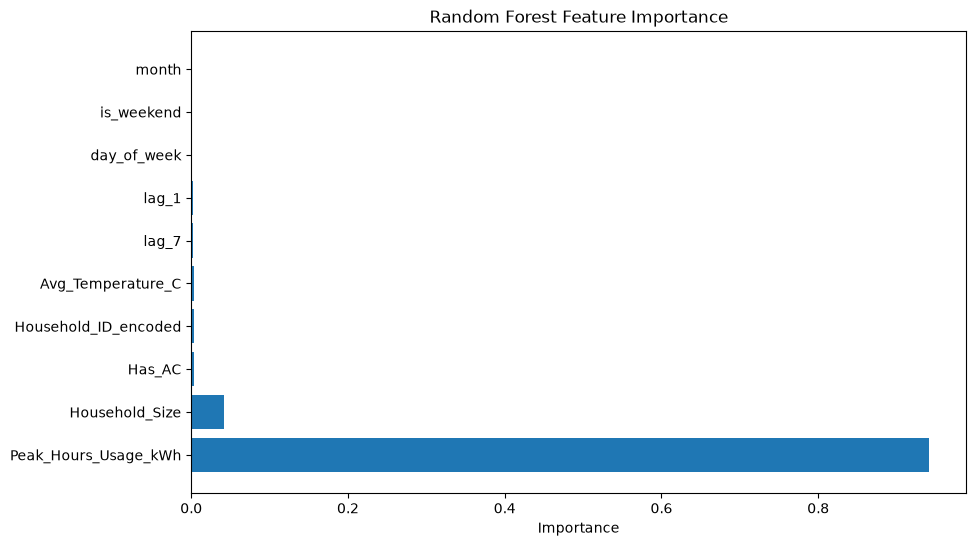

In [12]:
# -----------------------------
# Feature Importance
# -----------------------------

importance = pd.DataFrame({

    "Feature": X.columns,

    "Importance": rf_model.feature_importances_

})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance)

plt.figure(figsize=(10,6))

plt.barh(
    importance["Feature"],
    importance["Importance"]
)

plt.xlabel("Importance")

plt.title("Random Forest Feature Importance")

plt.show()

In [13]:
# -----------------------------
# Random Search
# -----------------------------

param_dist = {

    "n_estimators":[100,200,300,400],

    "max_depth":[10,20,30,None],

    "min_samples_split":[2,5,10],

    "min_samples_leaf":[1,2,4],

    "max_features":["sqrt","log2"]

}

random_search = RandomizedSearchCV(

    estimator=RandomForestRegressor(
        random_state=42,
        n_jobs=-1
    ),

    param_distributions=param_dist,

    n_iter=10,

    cv=3,

    random_state=42,

    scoring="r2",

    n_jobs=-1

)

random_search.fit(X_train,y_train)

print(random_search.best_params_)

{'n_estimators': 400, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 'log2', 'max_depth': 30}


In [14]:
# -----------------------------
# Grid Search
# -----------------------------

best = random_search.best_params_

param_grid = {

    "n_estimators":[best["n_estimators"]],

    "max_depth":[best["max_depth"]],

    "min_samples_split":[best["min_samples_split"]],

    "min_samples_leaf":[best["min_samples_leaf"]],

    "max_features":[best["max_features"]]

}

grid_search = GridSearchCV(

    estimator=RandomForestRegressor(
        random_state=42,
        n_jobs=-1
    ),

    param_grid=param_grid,

    cv=3,

    scoring="r2",

    n_jobs=-1

)

grid_search.fit(X_train,y_train)

best_rf = grid_search.best_estimator_

print("Best Parameters")
print(grid_search.best_params_)

Best Parameters
{'max_depth': 30, 'max_features': 'log2', 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 400}


In [15]:
# -----------------------------
# Final Evaluation
# -----------------------------

y_pred = best_rf.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test,y_pred))

r2 = r2_score(y_test,y_pred)

mape = mean_absolute_percentage_error(y_test,y_pred)

print("Final RMSE :",rmse)

print("Final R2 :",r2)

print("Final MAPE :",mape*100)

Final RMSE : 0.6656802994271991
Final R2 : 0.9855214282104025
Final MAPE : 6.047983113735015


                Feature  Importance
4  Peak_Hours_Usage_kWh    0.482425
1        Household_Size    0.282600
8                 lag_1    0.179451
3                Has_AC    0.039530
5           day_of_week    0.005783
2     Avg_Temperature_C    0.003382
9                 lag_7    0.003320
0  Household_ID_encoded    0.003149
7            is_weekend    0.000360
6                 month    0.000000


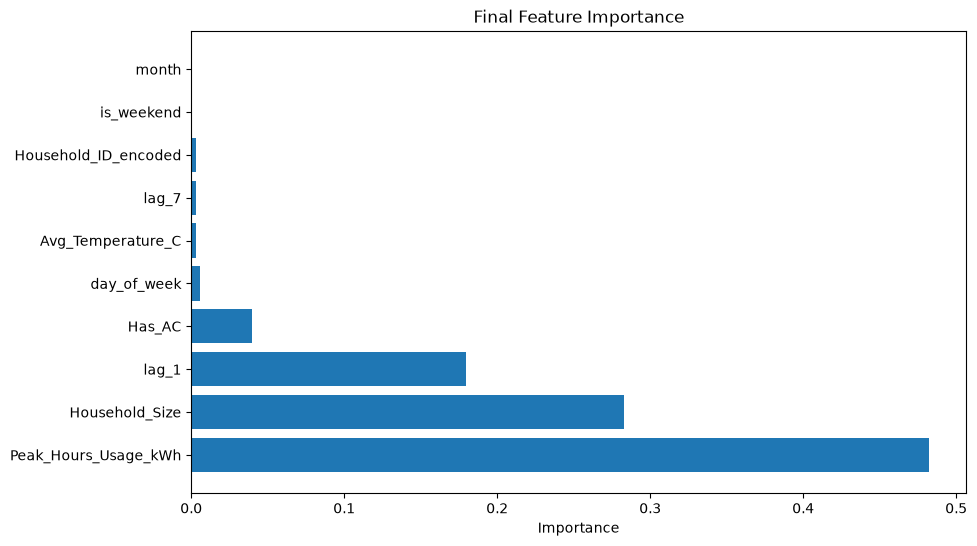

In [16]:
# -----------------------------
# Final Feature Importance
# -----------------------------

importance = pd.DataFrame({

    "Feature":X.columns,

    "Importance":best_rf.feature_importances_

})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance)

plt.figure(figsize=(10,6))

plt.barh(
    importance["Feature"],
    importance["Importance"]
)

plt.xlabel("Importance")

plt.title("Final Feature Importance")

plt.show()